In [1]:
import pandas as pd
from load import load_dataset

dataset = load_dataset("futbol_uruguayo.csv")

#print(dataset.head())


In [2]:
#separamos cronologicamente el conjunto de entrenamiento y el de evaluacion
#la evaluacion se mantiene separada hasta haber elegido los hiperparametros

train = dataset[
    dataset["date"] < pd.Timestamp("2024-01-01")
].copy()

test = dataset[
    (dataset["date"] >= pd.Timestamp("2024-01-01"))
    & (dataset["date"] < pd.Timestamp("2026-01-01"))
].copy()

print("Cantidad de partidos de entrenamiento:", len(train))
print("Cantidad de partidos de evaluacion:", len(test))

Cantidad de partidos de entrenamiento: 14734
Cantidad de partidos de evaluacion: 472


In [3]:
import sys
import os

from pipeline import create_model_pipeline, pipeline_input_attributes


# Agrega la carpeta padre (Tarea1) al path de búsqueda de Python
sys.path.append(os.path.abspath(".."))


#hacemos el arbol de decision usando solamente el conjunto de entrenamiento
from naiveBayes.bayes import M_Estimator as BayesClassifier

bayes= BayesClassifier(m=1.0)

model = create_model_pipeline(bayes)

In [4]:
X_train = train[pipeline_input_attributes].copy()
y_train = train["result"].copy()

X_test = test[pipeline_input_attributes].copy()
y_test = test["result"].copy()

print("Filas de entrenamiento:", len(X_train))
print("Filas reservadas para evaluacion final:", len(X_test))

Filas de entrenamiento: 14734
Filas reservadas para evaluacion final: 472


In [5]:
import numpy as np

#cada temporada se valida usando solamente las temporadas anteriores
# Validamos usando todo el historial moderno (desde 1950)
validation_years = list(range(1950, 2023))
train_years = train["date"].dt.year.to_numpy()
window_years = 5 # Agregamos la ventana de tiempo
temporal_splits = []

for validation_year in validation_years:
    fit_indices = np.flatnonzero(
        (train_years < validation_year) & (train_years >= validation_year - window_years)
    )
    validation_indices = np.flatnonzero(
        train_years == validation_year
    )

    temporal_splits.append((
        fit_indices,
        validation_indices
    ))

    print(
        f"Validacion {validation_year}:",
        f"entrenamiento={len(fit_indices)},",
        f"validacion={len(validation_indices)}"
    )

Validacion 1950: entrenamiento=412, validacion=93
Validacion 1951: entrenamiento=415, validacion=90
Validacion 1952: entrenamiento=415, validacion=91
Validacion 1953: entrenamiento=414, validacion=90
Validacion 1954: entrenamiento=454, validacion=90
Validacion 1955: entrenamiento=454, validacion=90
Validacion 1956: entrenamiento=451, validacion=90
Validacion 1957: entrenamiento=451, validacion=90
Validacion 1958: entrenamiento=450, validacion=90
Validacion 1959: entrenamiento=450, validacion=91
Validacion 1960: entrenamiento=451, validacion=91
Validacion 1961: entrenamiento=452, validacion=92
Validacion 1962: entrenamiento=454, validacion=90
Validacion 1963: entrenamiento=454, validacion=132
Validacion 1964: entrenamiento=496, validacion=90
Validacion 1965: entrenamiento=495, validacion=90
Validacion 1966: entrenamiento=494, validacion=90
Validacion 1967: entrenamiento=492, validacion=90
Validacion 1968: entrenamiento=492, validacion=90
Validacion 1969: entrenamiento=450, validacion=12

In [6]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Grilla de hiperparametros ampliada para Naive Bayes y discretizadores
param_grid = {
    # Diferencia de tasa de victorias / puntos
    # Antes: [0.0, 0.025, 0.05] (el mejor anterior fue 0.025)
    # Se amplía el rango y se añade mayor granularidad intermedia
    "preprocessing__differences__discretizer__record_margin": [
        0.0, 0.015, 0.025, 0.035, 0.05, 0.075, 0.10,
    ],

    # Diferencia de forma reciente (ultimos 5 partidos)
    # Antes: [0.10, 0.18, 0.25] (el mejor anterior fue 0.10, límite inferior)
    # Se exploran márgenes menores (< 0.10) y pasos más finos
    "preprocessing__differences__discretizer__last_matches_margin": [
        0.0, 0.04, 0.07, 0.10, 0.14, 0.18, 0.22, 0.26, 0.30,
    ],

    # Diferencia de goles general promedio
    # Antes: [0.30, 0.50, 0.70] (el mejor anterior fue 0.70, límite superior)
    # Se amplía hacia valores más altos (hasta 1.30) y pasos intermedios
    "preprocessing__differences__discretizer__goal_difference_margin": [
        0.20, 0.35, 0.50, 0.65, 0.70, 0.80, 0.95, 1.10, 1.30,
    ],

    # Diferencia de goles convertidos (ataque)
    # Antes: [0.0, 0.15, 0.30] (el mejor anterior fue 0.0)
    # Se añaden pasos intermedios entre 0.0 y 0.15 y valores superiores
    "preprocessing__differences__discretizer__attack_margin": [
        0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40,
    ],

    # Diferencia de goles recibidos (defensa)
    # Antes: [0.0, 0.15] (solo 2 valores, el mejor anterior fue 0.0)
    # Se añaden pasos intermedios y mayores
    "preprocessing__differences__discretizer__defense_margin": [
        0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30,
    ],

    # Priors (True = Sesgado históricamente, False = Uniforme/Equilibrado)
    "model__fit_prior": [
        True, False,
    ],

    # Valor de m para el m-estimador de Laplace/Bayes (suavizado)
    # Antes: [0.0, 1.0, 2.0, 5.0] (el mejor anterior fue 1.0)
    # Se afina alrededor de 1.0 y se prueban valores bajos y altos
    "model__m": [
        0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 7.5, 10.0,
    ],

    # Umbral bajo de tasa de empates
    # Antes: [0.15, 0.22, 0.28] (el mejor anterior fue 0.28, límite superior)
    "preprocessing__draw_rate__discretizer__low_threshold": [
        0.15, 0.18, 0.22, 0.25, 0.28, 0.30, 0.33,
    ],

    # Umbral alto de tasa de empates
    # Antes: [0.35, 0.42, 0.48] (el mejor anterior fue 0.48, límite superior)
    "preprocessing__draw_rate__discretizer__high_threshold": [
        0.35, 0.38, 0.42, 0.45, 0.48, 0.52, 0.55, 0.60,
    ],
}

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=1000, # Cantidad de combinaciones aleatorias a probar (puedes aumentarlo a 500 o más si dejas la compu corriendo)
    scoring=scoring,
    cv=temporal_splits, # 73 divisiones temporales
    n_jobs=-1,
    refit="f1_macro",
    random_state=42,
    verbose=1,
)

random_search.fit(X_train, y_train)

print("Mejores hiperparametros:")
print(random_search.best_params_)
print(f"Mejor F1-Macro temporal: {random_search.best_score_:.3%}")
best_acc = random_search.cv_results_["mean_test_accuracy"][random_search.best_index_]
print(f"Accuracy temporal del mejor modelo: {best_acc:.3%}")


Fitting 73 folds for each of 1000 candidates, totalling 73000 fits
Mejores hiperparametros:
{'preprocessing__draw_rate__discretizer__low_threshold': 0.3, 'preprocessing__draw_rate__discretizer__high_threshold': 0.55, 'preprocessing__differences__discretizer__record_margin': 0.075, 'preprocessing__differences__discretizer__last_matches_margin': 0.04, 'preprocessing__differences__discretizer__goal_difference_margin': 0.2, 'preprocessing__differences__discretizer__defense_margin': 0.25, 'preprocessing__differences__discretizer__attack_margin': 0.0, 'model__m': 0.0, 'model__fit_prior': False}
Mejor F1-Macro temporal: 42.165%
Accuracy temporal del mejor modelo: 47.486%


In [7]:
results = pd.DataFrame(random_search.cv_results_)

#buscamos automaticamente todas las columnas de hiperparametros
parameter_columns = [
    column
    for column in results.columns
    if column.startswith("param_")
]

# Generamos las columnas de score dinámicamente
split_columns = [f"split{i}_test_accuracy" for i in range(len(validation_years))]
score_columns = split_columns + [
    "mean_test_accuracy",
    "std_test_accuracy",
    "rank_test_accuracy",
]

results = results[
    parameter_columns + score_columns
].sort_values("rank_test_accuracy")

# Renombramos dinámicamente
rename_dict = {f"split{i}_test_accuracy": f"accuracy_{year}" for i, year in enumerate(validation_years)}
results = results.rename(columns=rename_dict)


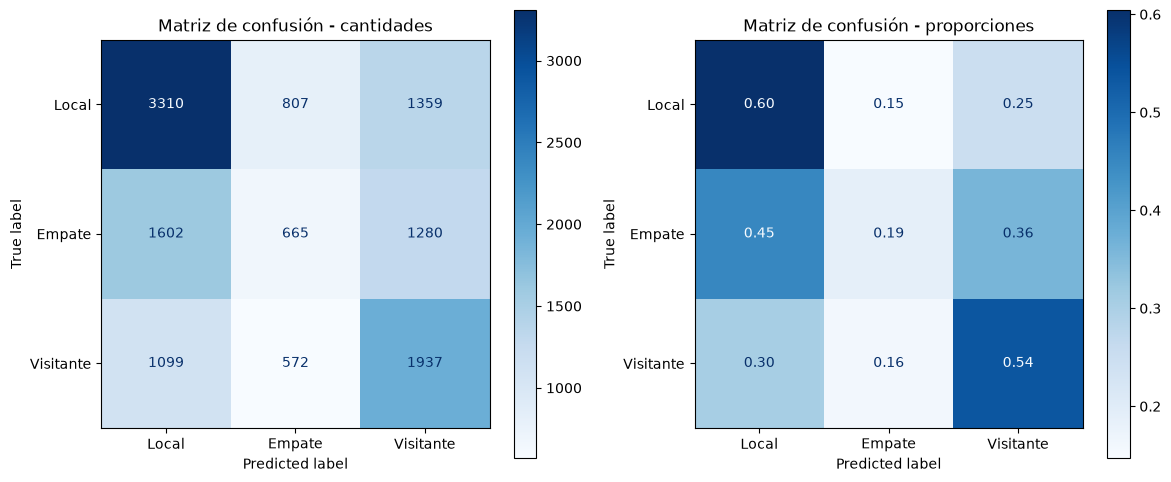

              precision    recall  f1-score   support

       Local       0.55      0.60      0.58      5476
      Empate       0.33      0.19      0.24      3547
   Visitante       0.42      0.54      0.47      3608

    accuracy                           0.47     12631
   macro avg       0.43      0.44      0.43     12631
weighted avg       0.45      0.47      0.45     12631



In [8]:
from sklearn.base import clone
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
)
import matplotlib.pyplot as plt
import numpy as np


real_results = []
predicted_results = []

#volvemos a entrenar el mejor modelo para cada division temporal
for fit_indices, validation_indices in temporal_splits:

    fold_model = clone(
        random_search.best_estimator_
    )

    fold_model.fit(
        X_train.iloc[fit_indices],
        y_train.iloc[fit_indices],
    )

    fold_predictions = fold_model.predict(
        X_train.iloc[validation_indices]
    )

    real_results.extend(
        y_train.iloc[validation_indices]
    )

    predicted_results.extend(
        fold_predictions
    )


real_results = np.asarray(real_results)
predicted_results = np.asarray(predicted_results)

labels = ["L", "E", "V"]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

#cantidad de partidos
ConfusionMatrixDisplay.from_predictions(
    real_results,
    predicted_results,
    labels=labels,
    display_labels=[
        "Local",
        "Empate",
        "Visitante",
    ],
    cmap="Blues",
    values_format="d",
    ax=axes[0],
)

axes[0].set_title(
    "Matriz de confusión - cantidades"
)

#porcentaje correcto dentro de cada clase real
ConfusionMatrixDisplay.from_predictions(
    real_results,
    predicted_results,
    labels=labels,
    display_labels=[
        "Local",
        "Empate",
        "Visitante",
    ],
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    ax=axes[1],
)

axes[1].set_title(
    "Matriz de confusión - proporciones"
)

plt.tight_layout()
plt.show()


print(
    classification_report(
        real_results,
        predicted_results,
        labels=labels,
        target_names=[
            "Local",
            "Empate",
            "Visitante",
        ],
        zero_division=0,
    )
)